In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv("../Datasets//train_energy_data.csv")

In [4]:
train_df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [6]:
train_df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [7]:
train_df.isnull().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [8]:
train_df.columns.tolist()

['Building Type',
 'Square Footage',
 'Number of Occupants',
 'Appliances Used',
 'Average Temperature',
 'Day of Week',
 'Energy Consumption']

In [9]:
train_df = train_df.rename(columns={'Building Type':'Building_Type','Square Footage':'Sq_Footage','Number of Occupants':'No._of_Occupants','Appliances Used':'Appliances_Used','Average Temperature':'Avg_Temp','Day of Week':'Day_of_Week','Energy Consumption':'Energy_Consumption'})
train_df

,Building_Type,Sq_Footage,No._of_Occupants,Appliances_Used,Avg_Temp,Day_of_Week,Energy_Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
...,...,...,...,...,...,...,...
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98


In [10]:
train_df.Building_Type.unique()

array(['Residential', 'Commercial', 'Industrial'], dtype=object)

In [11]:
train_df.dtypes

Building_Type          object
Sq_Footage              int64
No._of_Occupants        int64
Appliances_Used         int64
Avg_Temp              float64
Day_of_Week            object
Energy_Consumption    float64
dtype: object

In [12]:
train_df = pd.get_dummies(
    train_df,
    columns=['Building_Type', 'Day_of_Week'],
    drop_first=True
)

In [13]:
X = train_df.drop('Energy_Consumption', axis=1)

y = train_df['Energy_Consumption']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.981325676075111


In [18]:
X.columns

Index(['Sq_Footage', 'No._of_Occupants', 'Appliances_Used', 'Avg_Temp',
       'Building_Type_Industrial', 'Building_Type_Residential',
       'Day_of_Week_Weekend'],
      dtype='object')

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 97.1957525000002
MSE : 15206.507677652566
R2 Score : 0.981325676075111


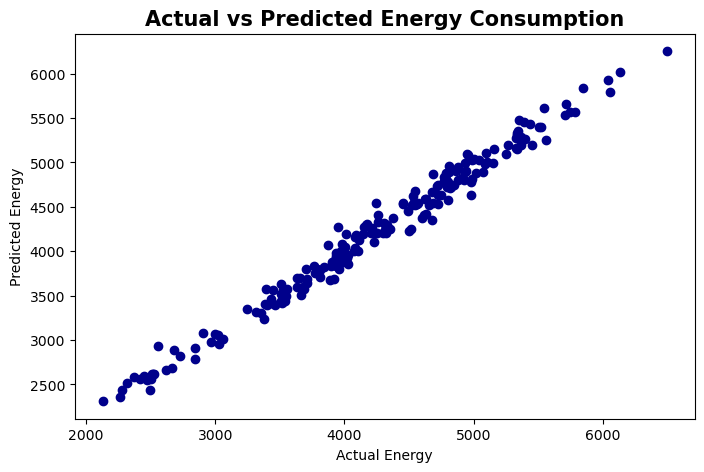

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, color='darkblue')

plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")

plt.title("Actual vs Predicted Energy Consumption",
          fontsize=15,
          fontweight='bold')

plt.show()

In [21]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [22]:
loaded_model = pickle.load(open("model.pkl", "rb"))

In [23]:
y_pred = model.predict(X_test)
y_pred

array([4678.0786, 2791.6132, 5568.433 , 4795.1825, 3804.6539, 2552.6314,
       5038.1892, 3315.6183, 4998.1049, 4202.4571, 3067.0863, 3686.2425,
       5167.9973, 4414.5589, 4543.2652, 3699.1417, 3560.1098, 4977.8837,
       4624.1923, 5313.2807, 4000.1822, 4637.896 , 4253.267 , 3412.1748,
       2622.8205, 3795.6523, 3793.7062, 2891.8006, 5257.2328, 4582.012 ,
       4727.3037, 4306.3985, 4000.8725, 5792.7103, 3953.0191, 5607.352 ,
       4070.4185, 3934.2889, 3561.4946, 4805.2443, 3639.4888, 2823.4856,
       4315.174 , 4901.4739, 5099.2024, 4334.7384, 3415.4012, 4630.0706,
       2364.0016, 4751.3896, 4544.6461, 5355.7957, 5835.5157, 5565.3297,
       3902.7694, 4108.8805, 4232.4151, 4278.0283, 2613.9462, 4558.927 ,
       2514.6939, 2563.2617, 2579.3094, 4200.5965, 4891.7437, 3597.4747,
       3492.9859, 4544.7065, 6017.7653, 2915.6397, 4310.9914, 3594.6008,
       5103.4026, 4748.6495, 3835.4256, 4828.7366, 4451.8889, 5022.0076,
       2618.7814, 4817.3002, 4233.9213, 3390.3246, 

In [24]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
521,4549.59,4678.0786
737,2842.91,2791.6132
740,5781.83,5568.4330
660,4773.54,4795.1825
411,3791.04,3804.6539
678,2470.59,2552.6314
626,5003.05,5038.1892
513,3314.12,3315.6183
859,5147.11,4998.1049
136,4298.92,4202.4571


In [25]:
results['Difference'] = abs(
    results['Actual'] - results['Predicted']
)

results.head(10)

,Actual,Predicted,Difference
521,4549.59,4678.0786,128.4886
737,2842.91,2791.6132,51.2968
740,5781.83,5568.4330,213.3970
660,4773.54,4795.1825,21.6425
411,3791.04,3804.6539,13.6139
678,2470.59,2552.6314,82.0414
626,5003.05,5038.1892,35.1392
513,3314.12,3315.6183,1.4983
859,5147.11,4998.1049,149.0051
136,4298.92,4202.4571,96.4629


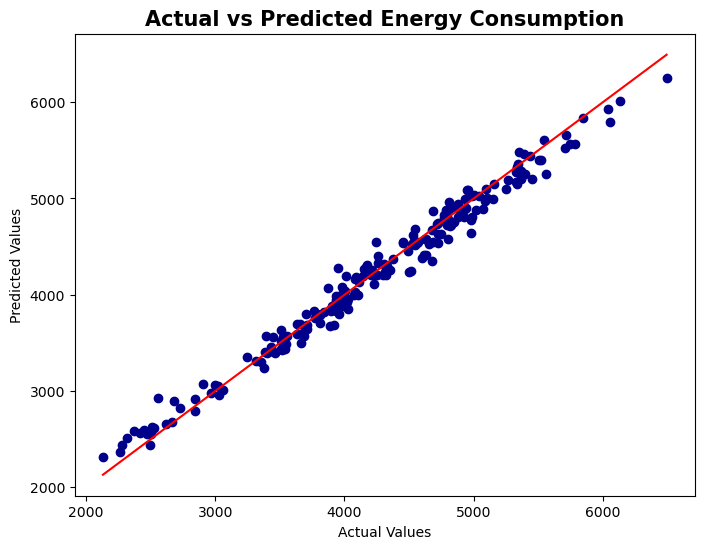

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='darkblue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Energy Consumption",
          fontsize=15,
          fontweight='bold')

plt.show()

In [27]:
sample1 = [[
    1000,   # Sq_Footage
    2,      # No._of_Occupants
    5,      # Appliances_Used
    25,     # Avg_Temp
    0,      # Building_Type_Industrial
    1,      # Building_Type_Residential
    0       # Day_of_Week_Weekend
]]

In [28]:
prediction = model.predict(sample1)

print(prediction)

[1945.5111]


In [29]:
sample2 = [[
    5000,   # Sq_Footage
    15,     # No._of_Occupants
    30,     # Appliances_Used
    35,     # Avg_Temp
    1,      # Building_Type_Industrial
    0,      # Building_Type_Residential
    1       # Day_of_Week_Weekend
]]

In [30]:
prediction = model.predict(sample2)

print(prediction)

[3390.7423]


In [31]:
prediction1 = model.predict(sample1)

prediction2 = model.predict(sample2)

print(prediction1)
print(prediction2)

[1945.5111]
[3390.7423]


In [32]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))